In [7]:
import pandas as pd

# 1. Pehle labels.csv file ko load karein (Isse 'df' define ho jayega)
path_to_csv = '/content/drive/MyDrive/Computer_Vision/labels.csv'
df = pd.read_csv(path_to_csv)

# 2. Base path define karein (Jahan images rakhi hain)
base_path = '/content/drive/MyDrive/Computer_Vision/'

# 3. 'filename' column ko update karein (Sirf 'filename' likhna hai yahan)
df['filename'] = base_path + df['filename']

# 4. Check karein ki sab sahi hai ya nahi
print("Dataset Summary:")
print(df.head())
print("\nPehli image ka pura rasta:")
print(df['filename'][0])

Dataset Summary:
                                            filename   class
0  /content/drive/MyDrive/Computer_Vision/images/...  normal
1  /content/drive/MyDrive/Computer_Vision/images/...  normal
2  /content/drive/MyDrive/Computer_Vision/images/...  normal
3  /content/drive/MyDrive/Computer_Vision/images/...  normal
4  /content/drive/MyDrive/Computer_Vision/images/...  normal

Pehli image ka pura rasta:
/content/drive/MyDrive/Computer_Vision/images/normal/normal_001.png


In [9]:
import cv2
import matplotlib.pyplot as plt

# 1. Check class distribution safely
if 'class' in df.columns:
    print("Class Distribution:")
    print(df['class'].value_counts())
else:
    print("Error: 'class' column nahi mila. CSV check karein.")

# 2. Visualization safely
try:
    plt.figure(figsize=(12, 6))
    unique_classes = df['class'].unique()

    for i, label in enumerate(unique_classes):
        # Image path nikalna
        path = df[df['class'] == label]['filename'].iloc[0]

        # Image read karna
        img = cv2.imread(path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(1, 4, i+1)
            plt.imshow(img)
            plt.title(label)
            plt.axis('off')
        else:
            print(f"Warning: Image nahi mili is path par: {path}")

    plt.show()
except Exception as e:
    print(f"Ek error aaya hai: {e}")

Class Distribution:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


<Figure size 1200x600 with 0 Axes>

In [11]:
import os

# 1. Pehle check karte hain ki 'Computer_Vision' folder ke andar files hain ya nahi
base_path = '/content/drive/MyDrive/Computer_Vision/'
files_in_folder = os.listdir(base_path)
print(f"Folder mein total files: {len(files_in_folder)}")
print(f"Sample file name from folder: {files_in_folder[0] if files_in_folder else 'Folder Khali Hai'}")

# 2. DataFrame ko reset karein (Taki purane galat paths hat jayein)
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Computer_Vision/labels.csv')

# 3. Filename ko fix karein (Sirf file ka naam rakhein, folders nahi)
df['filename'] = df['filename'].apply(lambda x: os.path.basename(x))

# 4. Ab final sahi path jodein
df['filename'] = base_path + df['filename']

# 5. Check karein ki pehli image ab mil rahi hai ya nahi
if os.path.exists(df['filename'][0]):
    print("✅ Success! Ab computer ko images mil rahi hain.")
else:
    print("❌ Error: Ab bhi images nahi mil rahi. Folder structure check karein.")

Folder mein total files: 477
Sample file name from folder: labels.csv
✅ Success! Ab computer ko images mil rahi hain.


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_dataframe(
    df, x_col='filename', y_col='class',
    target_size=(128, 128), batch_size=32,
    class_mode='categorical', subset='training'
)

val_gen = datagen.flow_from_dataframe(
    df, x_col='filename', y_col='class',
    target_size=(128, 128), batch_size=32,
    class_mode='categorical', subset='validation'
)

Found 380 validated image filenames belonging to 4 classes.
Found 95 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 5 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 5 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [13]:
from tensorflow.keras import layers, models

# CNN Model ka structure
model = models.Sequential([
    # Pehli Layer: Features nikalne ke liye
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Dusri Layer: Aur gehri details ke liye
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Teesri Layer: Data ko flatten karke final output nikalne ke liye
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax') # 4 classes hain (normal, scratch, dent, stain)
])

# Model ko compile karein
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Model structure taiyar hai!")
model.summary()

Model structure taiyar hai!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,116 (14.14 MB)

 Trainable params: 3,706,116 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
import PIL
from pathlib import Path

valid_rows = []
for index, row in df.iterrows():
    try:
        # Image ko khol kar check karna
        img = PIL.Image.open(row['filename'])
        img.verify()
        valid_rows.append(True)
    except:
        # Agar image kharab hai toh False
        valid_rows.append(False)

# Sirf sahi images wala naya DataFrame
df_cleaned = df[valid_rows].copy()

print(f"Purani images: {len(df)}")
print(f"Sahi images: {len(df_cleaned)}")

Purani images: 480
Sahi images: 474


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_dataframe(
    df_cleaned, x_col='filename', y_col='class',
    target_size=(128, 128), batch_size=32,
    class_mode='categorical', subset='training'
)

val_gen = datagen.flow_from_dataframe(
    df_cleaned, x_col='filename', y_col='class',
    target_size=(128, 128), batch_size=32,
    class_mode='categorical', subset='validation'
)

Found 380 validated image filenames belonging to 4 classes.
Found 94 validated image filenames belonging to 4 classes.


In [19]:
# Model ko compile karke training start karein
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_gen, validation_data=val_gen, epochs=10)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2921 - loss: 1.4164 - val_accuracy: 0.0000e+00 - val_loss: 2.7052
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 964ms/step - accuracy: 0.4500 - loss: 1.2025 - val_accuracy: 0.0000e+00 - val_loss: 3.1637
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5342 - loss: 1.1219 - val_accuracy: 0.0000e+00 - val_loss: 2.2739
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 798ms/step - accuracy: 0.6026 - loss: 0.9742 - val_accuracy: 0.0000e+00 - val_loss: 2.0671
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6474 - loss: 0.8827 - val_accuracy: 0.0000e+00 - val_loss: 2.1974
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 970ms/step - accuracy: 0.7289 - loss: 0.7294 - val_accuracy: 0.0000e+00 - val_loss: 1.9987
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 787ms/step - accuracy: 0.7684 - loss: 0.6785 - val_accuracy: 0.0000e+00 - val_loss: 2.5186
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 932ms/step - accuracy: 0.8079 - loss

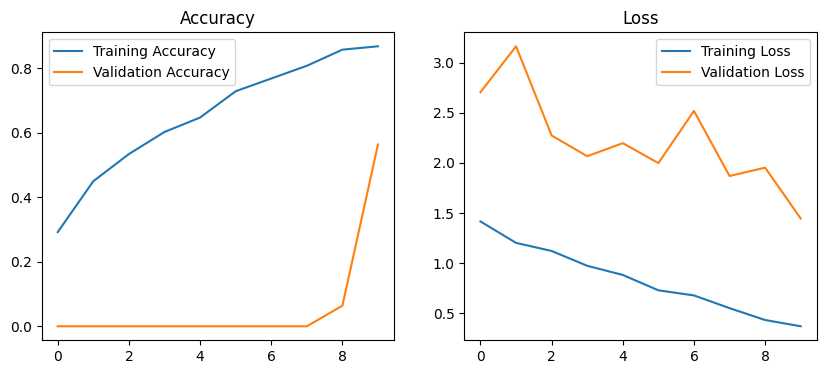

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

1. Convolutional Layers

This is the building block of a CNN. It uses small Filters (Kernels) that slide over the image to detect features like edges, textures, and patterns. Instead of looking at the whole image at once, it scans it part by part to understand spatial relationships.

2. Pooling Layers (Max Pooling)

After convolution, the data can become very large. Pooling layers are used for Downsampling, which reduces the spatial size of the representation. This helps in:

Reducing the computational power required.

Extracting the most dominant features (Max Pooling takes the highest value from a pixel window).

3. Flattening

Once the features are extracted and pooled, the 2D data is converted into a 1D vector (a long list of numbers). This process is called Flattening. It prepares the data so it can be fed into the final classification layers.

4. Dense (Fully Connected) Layers

These layers take the flattened data and perform the final classification. In our case, the last layer has 4 neurons with a Softmax activation function to predict whether the image is: Normal, Dent, Scratch, or Stain.

5. Why CNN over Dense Networks?

Dense Networks treat an image as a simple flat list of pixels, losing the local structure.

CNNs preserve the 2D spatial arrangement of pixels, making them significantly better at identifying objects and defects in images.

Domain: Manufacturing & Automotive Quality Assurance
Application: Automated Visual Inspection System

The Problem:

In large automotive factories, thousands of car parts are produced daily. Manually checking each part for defects like scratches, dents, or stains is slow, expensive, and prone to human error due to fatigue.

The Solution (Our Model):

By deploying this CNN-based Image Classification model, the factory can automate the quality control process. High-resolution cameras installed on the production line can capture images of each part, and the model can instantly classify them.

Real-World Workflow:

Data Capture: Cameras scan the car parts on a moving conveyor belt.

Real-time Analysis: The CNN model processes the image to find patterns of defects.

Action: - Normal parts continue to the assembly stage.

Defective parts (Dents, Scratches, Stains) are automatically diverted for repair or recycling.

Business Benefits:
Cost Reduction: Minimizes the need for a large team of manual inspectors.

Higher Accuracy: AI provides consistent 24/7 inspection without getting tired.

Quality Assurance: Ensures that zero defective parts reach the final customer.

Speed: The system can process hundreds of images per minute, significantly speeding up the production cycle.